In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import netCDF4 as nc

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as T

In [2]:
df = pd.read_csv("quantum_spin_bit_meas.txt", sep=r"\s+", header=None, skiprows=1)
df.columns = ["angle_deg", "bit_value"]
df

,angle_deg,bit_value
0,0.000000,0.0
1,0.180180,0.0
2,0.360360,0.0
3,0.540541,0.0
4,0.720721,0.0
...,...,...
995,179.279279,1.0
996,179.459459,1.0
997,179.639640,1.0
998,179.819820,1.0


In [3]:
# feature matrix and labels
X = df[["angle_deg"]].values
y = df["bit_value"].astype(int).values

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# logistic Regression
log_reg = LogisticRegression(solver="lbfgs", max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [4]:
y_pred = log_reg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc}")
print(f"Precision: {prec}")
print(f"Recall   : {rec}")
print(f"F1-score : {f1}")

Accuracy : 0.81
Precision: 0.7880794701986755
Recall   : 0.8263888888888888
F1-score : 0.8067796610169492


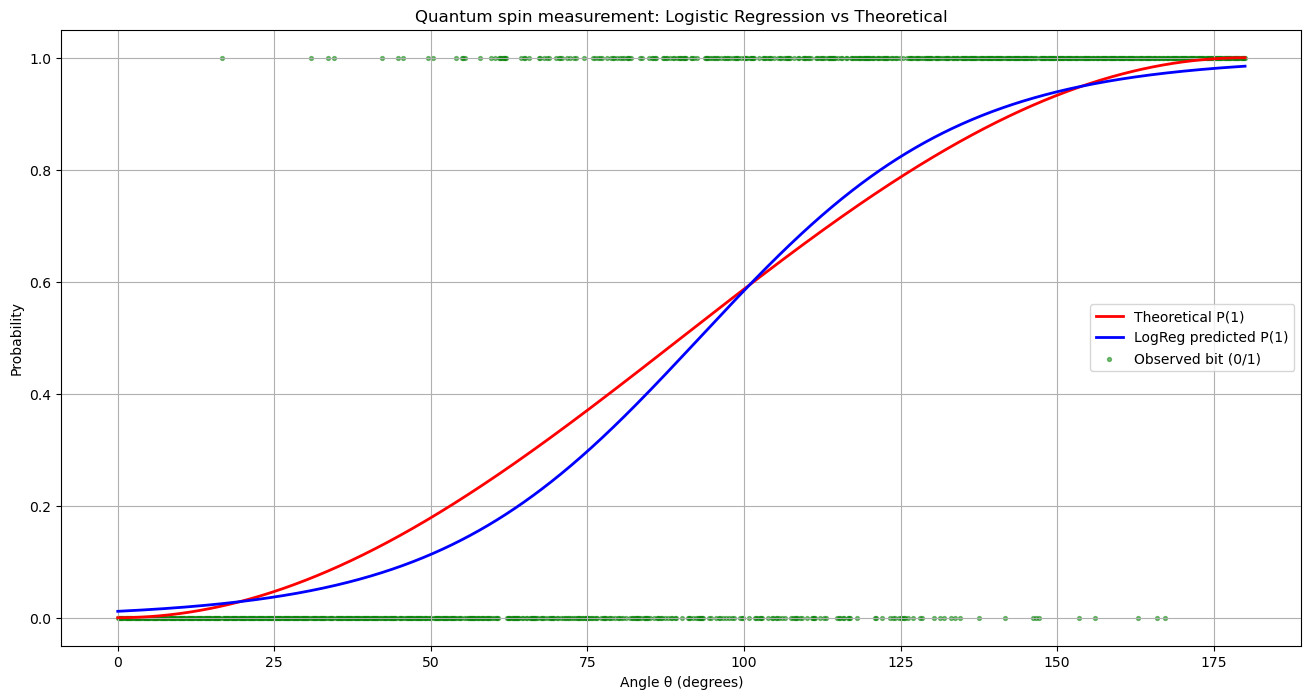

In [5]:
# predicted probabilities for all angles
angles_deg = df["angle_deg"].values
pred_prob_all = log_reg.predict_proba(angles_deg.reshape(-1, 1))[:, 1]

# theoretical probability: P(1) = sin^2(theta/2)
angles_rad = np.deg2rad(angles_deg)
qm_prob_all = np.sin(angles_rad / 2) ** 2

plt.figure(figsize=(16, 8))
plt.plot(angles_deg, qm_prob_all, label="Theoretical P(1)", color="red", lw=2)
plt.plot(angles_deg, pred_prob_all, label="LogReg predicted P(1)", color="blue", lw=2)
plt.scatter(angles_deg, df["bit_value"].values, label="Observed bit (0/1)", color="green", s=8, alpha=0.5)

plt.xlabel("Angle θ (degrees)")
plt.ylabel("Probability")
plt.title("Quantum spin measurement: Logistic Regression vs Theoretical")
plt.legend()
plt.grid()
plt.show()

---

Filename: Bias-20240823_201054.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2048, 2048)   int16 (rescales to uint16)   
SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   16 / number of bits per data pixel                  NAXIS   =                    2 / number of data axes                            NAXIS1  =                 2048 / length of data axis 1                          NAXIS2  =                 2048 / length of data axis 2                          EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy andCOMMENT   Astrophysics Supplement Series v44/p363, v44/p371, v73/p359, v73/p365.COMMENT   Contact the NASA Science Office of Standards and Technology for the   COMMENT   FITS Definition document #100 and other FITS information.             BZERO   =      

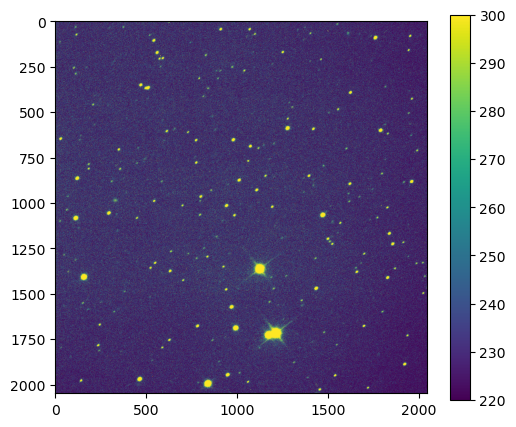

In [6]:
sky_fn = 'M_JUCIE-Rc-60s-20240823_203742.fits'
bias_fn = 'Bias-20240823_201054.fits'
# Open the bias FITS file
b_file = fits.open(bias_fn)
# Print the info about the FITS file
b_file.info()
# Get the binary data
I_b = b_file[0].data
# Close the FITS file
b_file.close()

sky_file = fits.open(sky_fn)
I_sky = sky_file[0].data
I_shape = I_sky.shape
print(sky_file[0].header)
sky_file.close()

I_cal = I_sky - I_b
plt.figure(figsize = (6,5))
plt.imshow(I_cal, vmin=220, vmax = 300)
plt.colorbar()

I_sub = I_cal[1682:1762,1155:1235]

# Data preparation can be down with a loop going throw row and column indices
# The followinng code allows us to use numpy vectorization to save time
rr = np.tile(np.linspace(1, I_shape[0], I_shape[0]).reshape((-1,1)), (1, I_shape[1]))
cc = np.tile(np.linspace(1, I_shape[1], I_shape[1]).reshape((1,-1)), (I_shape[0], 1))

y = I_sub.reshape(-1)
X = np.hstack((rr.reshape(-1), cc.reshape(-1)))

In [7]:
# subimage bounds from Cell 1
r0, r1 = 1682, 1762  # rows 1682:1762
c0, c1 = 1155, 1235  # cols 1155:1235

# rr/cc to the subimage region (rr, cc are created in Cell 1)
rr_sub = rr[r0:r1, c0:c1]
cc_sub = cc[r0:r1, c0:c1]

# background subtraction
y_raw = I_sub.reshape(-1).astype(float)

border = np.concatenate([I_sub[0,:], I_sub[-1,:], I_sub[:,0], I_sub[:,-1]])
bg = float(np.median(border))
y = y_raw - bg  # background subtracted intensity

print(f"[Info] Background (median border): {bg}")
print(f"[Info] y_raw range: [{y_raw.min()}, {y_raw.max()}]  (dyn = {y_raw.max()-y_raw.min()})")
print(f"[Info] y (backgroung subtracted): [{y.min()}, {y.max()}]  (dyn = {y.max()-y.min()})")

# local (row, col) coordinates for the 80x80 grid
# local coordinates (0..79), will be scaled later
rows_local, cols_local = np.indices(I_sub.shape)  # (80,80) each
X = np.column_stack([rows_local.reshape(-1), cols_local.reshape(-1)])  # (6400, 2)

# 40/30/30 split
X_rem, X_test, y_rem, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, train_size=4/7, random_state=42, shuffle=True)

print(f"[Split] Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

[Info] Background (median border): 261.0
[Info] y_raw range: [156.0, 58676.0]  (dyn = 58520.0)
[Info] y (backgroung subtracted): [-105.0, 58415.0]  (dyn = 58520.0)
[Split] Train: 2560  Val: 1920  Test: 1920


In [8]:
# baseline predictor, constant mean of y_train
ybar_val = np.full_like(y_val, y_train.mean())
ybar_test = np.full_like(y_test, y_train.mean())

baseline_val_mse = mean_squared_error(y_val, ybar_val)
baseline_test_mse = mean_squared_error(y_test, ybar_test)

def report_mses(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    dyn = y_true.max() - y_true.min()  # dynamic range of this split (background subtracted)
    nrmse = rmse / dyn if dyn > 0 else np.nan
    print(f"{name}: MSE={mse}, RMSE={rmse}, nRMSE={nrmse}")
    return mse, rmse, nrmse

print("[Baseline] Using mean(y_train) on background subtracted target:")
_ = report_mses("Val (baseline)", y_val, ybar_val)
_ = report_mses("Test (baseline)", y_test, ybar_test)

# show original (non subtracted) dynamic range
orig_dyn = y_raw.max() - y_raw.min()
print(f"[Info] Original intensity dynamic range (no background subtracted): {orig_dyn}")

[Baseline] Using mean(y_train) on background subtracted target:
Val (baseline): MSE=100395898.95248432, RMSE=10019.775394313205, nRMSE=0.17126064667407112
Test (baseline): MSE=83255327.45215474, RMSE=9124.435733356597, nRMSE=0.15593327750758945
[Info] Original intensity dynamic range (no background subtracted): 58520.0


In [9]:
# scale X, SVR, then scale y via TransformedTargetRegressor
pipe = Pipeline([
    ("x_scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svr", SVR(kernel="rbf"))
])

model = TransformedTargetRegressor(
    regressor=pipe,
    transformer=StandardScaler(with_mean=True, with_std=True)  # scale y
)

param_grid = {
    "regressor__svr__gamma": np.logspace(-2, 3, 40),
    "regressor__svr__C": [1, 3, 10, 30, 100],
    "regressor__svr__epsilon": [0.01, 0.03, 0.1]
}

gs = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=10,
    n_jobs=-1,
    verbose=1
)

# fit only on training data
gs.fit(X_train, y_train)
best_model = gs.best_estimator_

print("\n[GridSearch] Best params:", gs.best_params_)
print("[GridSearch] Best CV MSE:", -gs.best_score_)

# validation and test sets (background subtracted space)
y_pred_val = best_model.predict(X_val)
y_pred_test = best_model.predict(X_test)

val_mse = mean_squared_error(y_val, y_pred_val)
test_mse = mean_squared_error(y_test, y_pred_test)
val_rmse = np.sqrt(val_mse)
test_rmse = np.sqrt(test_mse)

# nRMSE relative to each split's background subtracted dynamic range
val_dyn = y_val.max() - y_val.min()
test_dyn = y_test.max() - y_test.min()
val_nrmse = val_rmse / val_dyn if val_dyn > 0 else np.nan
test_nrmse = test_rmse / test_dyn if test_dyn > 0 else np.nan

print(f"\n[Background subtracted] Val MSE={val_mse}, RMSE={val_rmse}, nRMSE={val_nrmse}")
print(f"[Background subtracted] Test MSE={test_mse}, RMSE={test_rmse}, nRMSE={test_nrmse}")

# report metrics back in original (add background back to predictions)
y_val_orig   = y_val + bg
y_test_orig  = y_test + bg
y_pred_val_o = y_pred_val + bg
y_pred_test_o= y_pred_test + bg

val_mse_o = mean_squared_error(y_val_orig, y_pred_val_o)
test_mse_o = mean_squared_error(y_test_orig, y_pred_test_o)
val_rmse_o = np.sqrt(val_mse_o)
test_rmse_o = np.sqrt(test_mse_o)

orig_dyn = y_raw.max() - y_raw.min()
val_nrmse_o = val_rmse_o / orig_dyn if orig_dyn > 0 else np.nan
test_nrmse_o = test_rmse_o / orig_dyn if orig_dyn > 0 else np.nan

print(f"\n[Original] Val MSE={val_mse_o}, RMSE={val_rmse_o}, nRMSE wrt orig dyn={val_nrmse_o}")
print(f"[Original] Test MSE={test_mse_o}, RMSE={test_rmse_o}, nRMSE wrt orig dyn={test_nrmse_o}")

# keep best params
best_params = gs.best_params_

Fitting 10 folds for each of 600 candidates, totalling 6000 fits

[GridSearch] Best params: {'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.01, 'regressor__svr__gamma': np.float64(52.23345074266838)}
[GridSearch] Best CV MSE: 241605.65213340678

[Background subtracted] Val MSE=321617.23311989143, RMSE=567.1130690787256, nRMSE=0.009693246317962699
[Background subtracted] Test MSE=225972.43640107056, RMSE=475.36558184314373, nRMSE=0.008123824350049453

[Original] Val MSE=321617.23311989143, RMSE=567.1130690787256, nRMSE wrt orig dyn=0.009690927359513424
[Original] Test MSE=225972.43640107056, RMSE=475.36558184314373, nRMSE wrt orig dyn=0.008123130243389332


best gamma: {'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.01, 'regressor__svr__gamma': np.float64(52.23345074266838)}


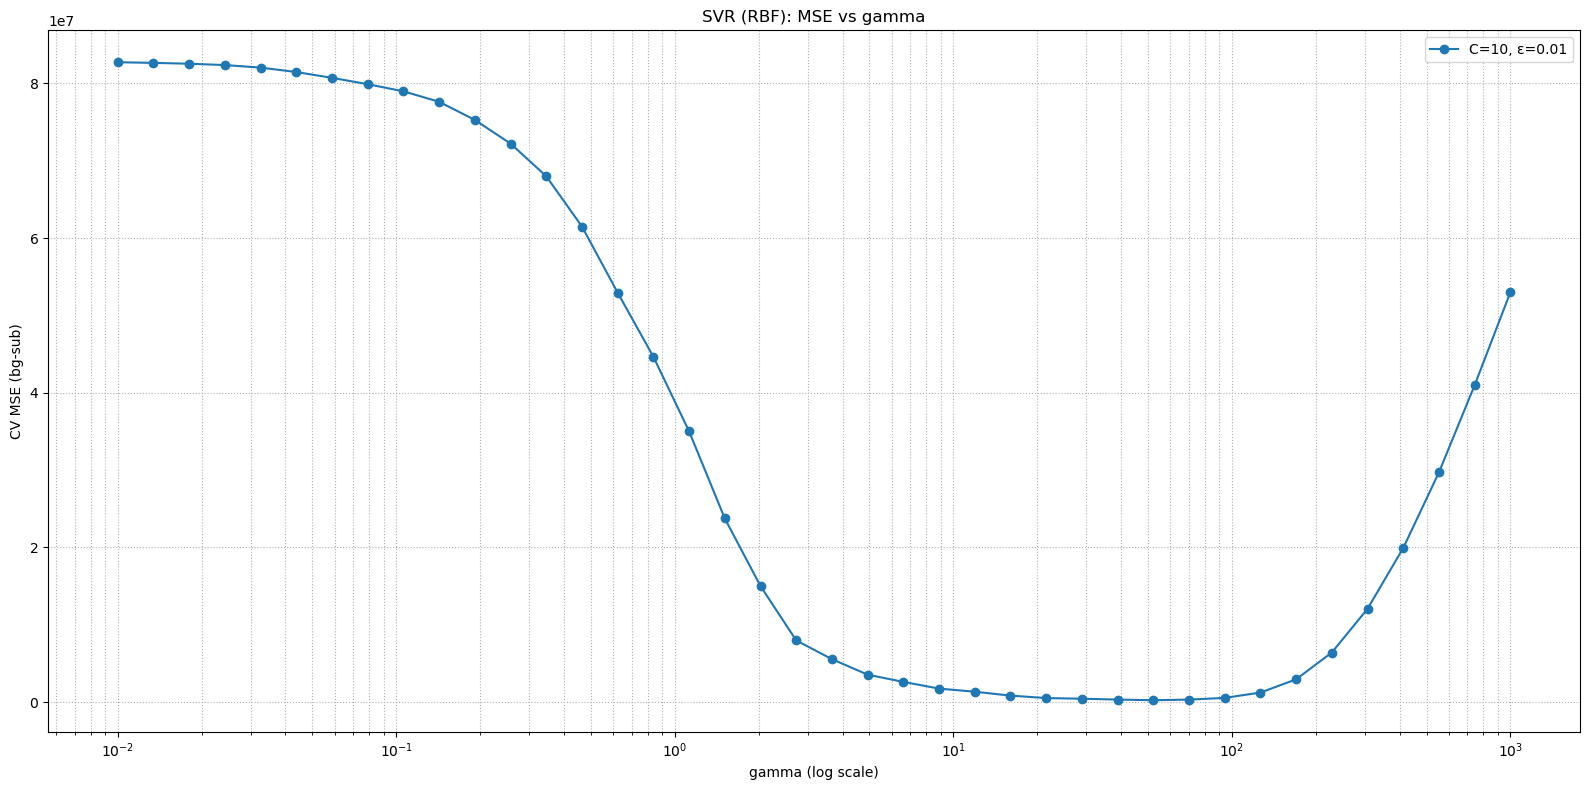

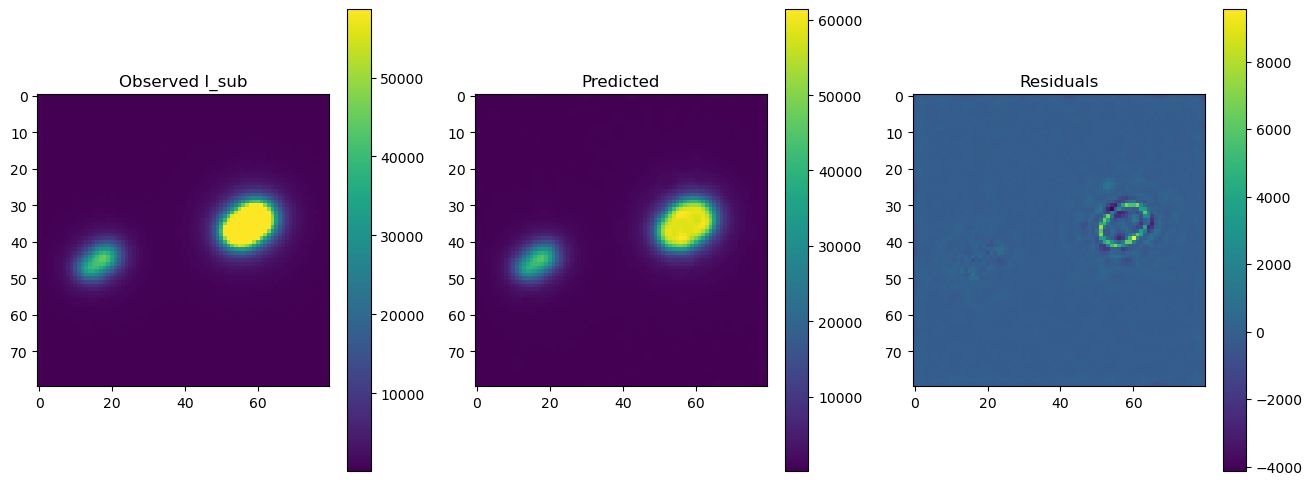

In [10]:
# build DataFrame from cv_results_
cv = gs.cv_results_
df = pd.DataFrame({
    "mean_test_MSE": -cv["mean_test_score"],
    "gamma": cv["param_regressor__svr__gamma"].data.astype(float),
    "C": cv["param_regressor__svr__C"].data.astype(int),
    "epsilon": cv["param_regressor__svr__epsilon"].data.astype(float),
})

# filter best C and epsilon for gamma curve
C_best = best_params["regressor__svr__C"]
eps_best = best_params["regressor__svr__epsilon"]
df_best = df[(df["C"] == C_best) & (df["epsilon"] == eps_best)].sort_values("gamma")

plt.figure(figsize=(16, 8))
plt.semilogx(df_best["gamma"], df_best["mean_test_MSE"], "o-", label=f"C={C_best}, ε={eps_best}")
plt.xlabel("gamma (log scale)")
plt.ylabel("CV MSE (bg-sub)")
plt.title("SVR (RBF): MSE vs gamma")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()

# predicted field on the whole 80x80 grid (original)
X_grid = np.column_stack([rows_local.reshape(-1), cols_local.reshape(-1)])
I_pred_bgsub = best_model.predict(X_grid).reshape(I_sub.shape)
I_pred_orig = I_pred_bgsub + bg
resid_orig = I_sub - I_pred_orig

plt.figure(figsize=(16, 8))
plt.subplot(1, 3, 1)
plt.imshow(I_sub, origin="upper")
plt.title("Observed I_sub")
plt.colorbar(shrink=0.75)

plt.subplot(1, 3, 2)
plt.imshow(I_pred_orig, origin="upper")
plt.title("Predicted")
plt.colorbar(shrink=0.75)

plt.subplot(1, 3, 3)
plt.imshow(resid_orig, origin="upper")
plt.title("Residuals")
plt.colorbar(shrink=0.75)

print(f"best gamma: {best_params}")

---

In [11]:
fn = 'SeaSurfaceTemperature_monthly_187001-202402.nc'
sst_data = nc.Dataset(fn)
lon = sst_data['longitude'][:]
lat = sst_data['latitude'][:]
sst = sst_data['sst'][:]
sst.mask[sst == -1000] = True

from netCDF4 import num2date

# Ensure (time, lat, lon) order
dims = sst_data['sst'].dimensions
dim_map = {name: i for i, name in enumerate(dims)}
tix = dim_map.get('time', 0)
lax = dim_map.get('latitude', 1)
lix = dim_map.get('longitude', 2)
if (tix, lax, lix) != (0, 1, 2):
    sst = np.moveaxis(sst, (tix, lax, lix), (0, 1, 2))

# decode time axis (robust)
time_var = sst_data.variables.get('time', None)
times = None
if time_var is not None:
    try:
        times = num2date(time_var[:], units=time_var.units,
                         calendar=getattr(time_var, 'calendar', 'standard'),
                         only_use_cftime_datetimes=False)  # supported on newer netCDF4
    except TypeError:
        times = num2date(time_var[:], units=time_var.units,
                         calendar=getattr(time_var, 'calendar', 'standard')) # fallback for older netCDF4

# region bound
LAT_MIN, LAT_MAX = -30, 30
LON_MIN_TARGET, LON_MAX_TARGET = -150, -120

# latitude mask
lat_mask = (lat >= LAT_MIN) & (lat <= LAT_MAX)

# longitude mask: handle 0..360 vs -180..180
if lon.min() >= 0 and lon.max() <= 360:
    lmin = LON_MIN_TARGET % 360  # -150 -> 210
    lmax = LON_MAX_TARGET % 360  # -120 -> 240
    lon_mask = (lon >= lmin) & (lon <= lmax)
else:
    lon_mask = (lon >= LON_MIN_TARGET) & (lon <= LON_MAX_TARGET)

lat_idx = np.where(lat_mask)[0]
lon_idx = np.where(lon_mask)[0]
if lat_idx.size == 0 or lon_idx.size == 0:
    raise ValueError("No grid points found in the region. Check longitude convention/bounds.")

# subset SST: (time, lat, lon)
sst_sub = sst[:, lat_idx[:, None], lon_idx[None, :]]
ntime, nlat, nlon = sst_sub.shape

# prepare lat/lon arrays for subset (used for weighting & mapping)
lat_sub = lat[lat_idx]
lon_sub = lon[lon_idx]

print(f"SST subset shape: time={ntime}, lat={nlat}, lon={nlon}")
print(f"Latitude range: {lat_sub.min()} to {lat_sub.max()} deg")
print(f"Longitude range: {lon_sub.min()} to {lon_sub.max()} deg")

SST subset shape: time=1850, lat=60, lon=30
Latitude range: -29.5 to 29.5 deg
Longitude range: -149.5 to -120.5 deg


In [12]:
USE_ANOMALIES = True
USE_AREA_WEIGHTING = True # weight using sqrt(cos(latitude))

# convert masked to NaN for filtering
sst_sub_np = np.ma.filled(sst_sub, np.nan)

# reshape
X = sst_sub_np.reshape(ntime, nlat * nlon)

# drop feature columns (grid points) with any NaN across time (ignore land/missing)
valid_cols = ~np.isnan(X).any(axis=0)
X_valid = X[:, valid_cols]

# anomalies
if USE_ANOMALIES and (times is not None) and (len(times) == ntime):
    months = np.array([t.month for t in times])
    X_anom = X_valid.copy()
    # subtract month-specific climatology per feature column
    for m in range(1, 13):
        mask_m = (months == m)
        if np.any(mask_m):
            climatology = np.nanmean(X_valid[mask_m, :], axis=0)
            X_anom[mask_m, :] = X_valid[mask_m, :] - climatology
    X_work = X_anom
    print("Applied monthly climatology anomalies")
else:
    X_work = X_valid
    if USE_ANOMALIES:
        print("Anomalies requested but 'times' unavailable/mismatched; proceeding without anomalies.")

# area weighting
if USE_AREA_WEIGHTING:
    # build weight vector aligned to columns of X_valid
    # for each valid column (flattened (lat,lon)), get its lat index
    # create lat index grid for the subset
    lat_indices_grid = np.repeat(np.arange(nlat)[:, None], nlon, axis=1).reshape(nlat * nlon)
    lat_indices_valid = lat_indices_grid[valid_cols]
    lat_for_cols = lat_sub[lat_indices_valid]
    w_vec = np.sqrt(np.cos(np.deg2rad(np.clip(lat_for_cols, -89.9, 89.9))))  # avoid cos(±90)
    # apply weighting to features (columns)
    Xw = X_work * w_vec[np.newaxis, :]
    print("Applied area weighting")
else:
    Xw = X_work
    w_vec = None

print(f"Total grid cells in subset: {nlat * nlon}")
print(f"Valid ocean grid cells used: {X_valid.shape[1]}")
print(f"Data matrix for PCA: shape={Xw.shape} (time x features)")

Applied monthly climatology anomalies
Applied area weighting
Total grid cells in subset: 1800
Valid ocean grid cells used: 1800
Data matrix for PCA: shape=(1850, 1800) (time x features)


Explained variance ratio (first 10 modes or fewer):
  PC1: 60.26469039916992%
  PC2: 15.095236778259277%
  PC3: 5.748047828674316%
  PC4: 5.255475997924805%
  PC5: 3.0674564838409424%
  PC6: 1.3845728635787964%
  PC7: 1.1109709739685059%
  PC8: 0.9264405965805054%
  PC9: 0.7764442563056946%
  PC10: 0.5390239357948303%


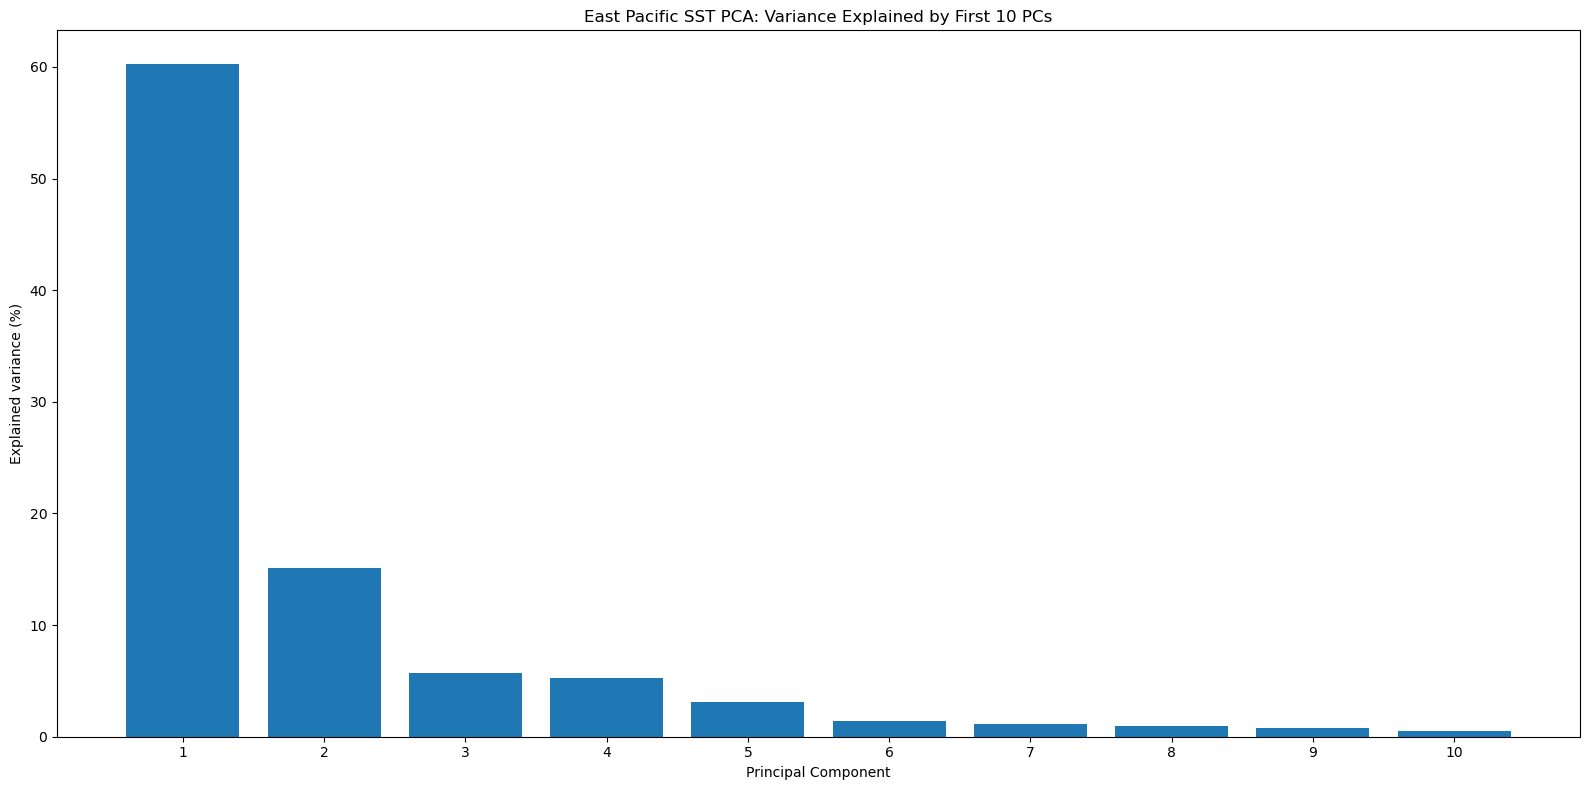

In [13]:
# Limit components by samples/features
ncomp_show = min(10, Xw.shape[0], Xw.shape[1])

pca10 = PCA(n_components=ncomp_show, svd_solver='auto')
scores10 = pca10.fit_transform(Xw)                 # PC time series (per mode)
evr10 = pca10.explained_variance_ratio_            # fraction of variance per mode

# Print explained variance percentages
print("Explained variance ratio (first 10 modes or fewer):")
for i, r in enumerate(evr10, start=1):
    print(f"  PC{i}: {r*100}%")

plt.figure(figsize=(16, 8))
plt.bar(np.arange(1, ncomp_show + 1), evr10 * 100)
plt.xticks(np.arange(1, ncomp_show + 1))
plt.xlabel('Principal Component')
plt.ylabel('Explained variance (%)')
plt.title("East Pacific SST PCA: Variance Explained by First 10 PCs")
plt.tight_layout()

5-PC cumulative explained variance: 89.43090438842773%
Overall MSE (same units as X_target, °C^2): 0.03411634832000213
Overall RMSE (°C): 0.17820073327125852


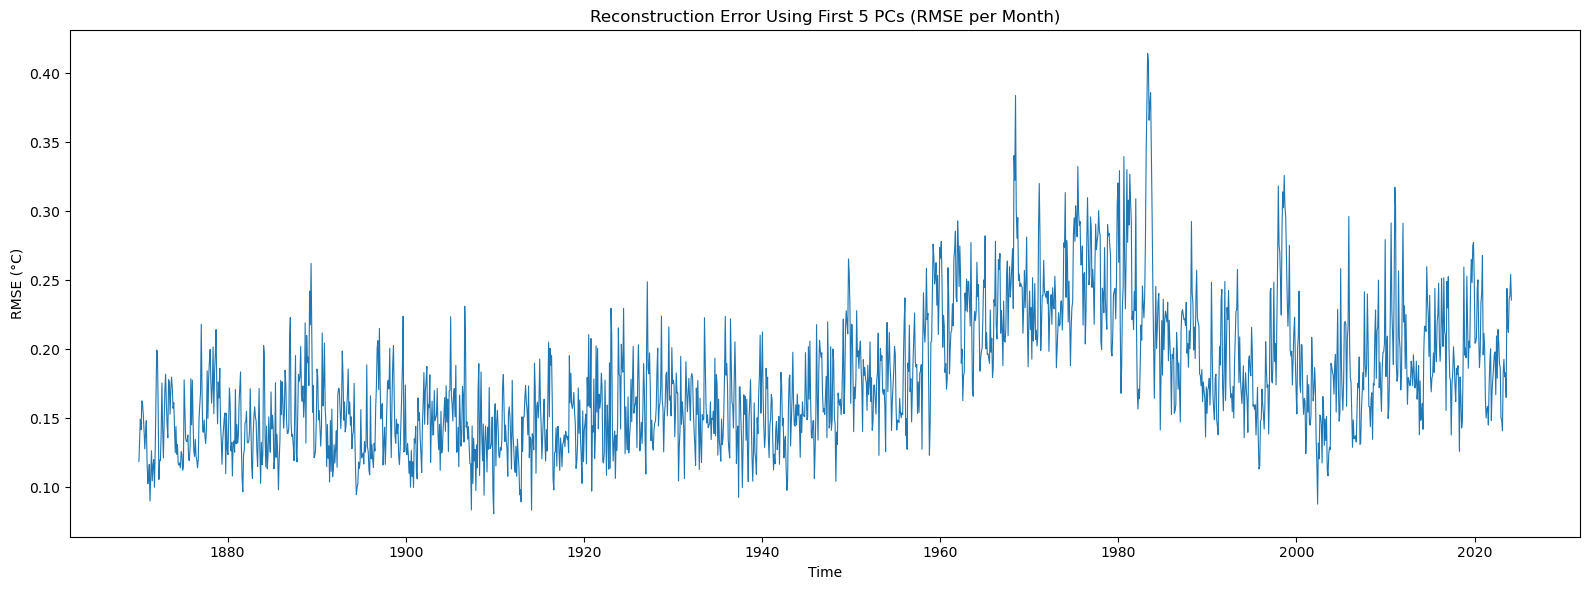

In [14]:
ncomp_recon = min(5, Xw.shape[0], Xw.shape[1])

pca5 = PCA(n_components=ncomp_recon, svd_solver='auto')
scores5 = pca5.fit_transform(Xw)
Xw_recon = pca5.inverse_transform(scores5)

# if applied area weighting, unweight to compare in original units
if w_vec is not None:
    X_recon = Xw_recon / w_vec[np.newaxis, :]
    X_target = X_work
else:
    X_recon = Xw_recon
    X_target = X_work

# performance metrics in the same space as X_target
mse_per_time = np.mean((X_target - X_recon)**2, axis=1)
rmse_per_time = np.sqrt(mse_per_time)
overall_mse = float(np.mean(mse_per_time))
overall_rmse = float(np.mean(rmse_per_time))
cumvar5 = float(np.sum(pca5.explained_variance_ratio_))

print(f"5-PC cumulative explained variance: {cumvar5*100}%")
print(f"Overall MSE (same units as X_target, °C^2): {overall_mse}")
print(f"Overall RMSE (°C): {overall_rmse}")

# x axis for plotting
def build_time_axis(times_obj, n_expected):
    x_axis = np.arange(n_expected)
    if times_obj is None or len(times_obj) != n_expected:
        return x_axis, False, "times None or length mismatch"
    try:
        t = np.array(times_obj)
        try:
            import cftime
            if t.size > 0 and isinstance(t[0], cftime.datetime):
                t = np.array([tt.to_datetime() for tt in t])
        except Exception:
            pass
        # guard against masked arrays or '?' placeholders
        if np.ma.isMaskedArray(t):
            raise ValueError("masked time axis")
        if t.dtype == object and any(isinstance(v, str) and v.strip() == '?' for v in t):
            raise ValueError("string '?' in time axis")
        return t, True, "ok"
    except Exception as e:
        return np.arange(n_expected), False, f"fallback: {e}"

x_axis, use_times, msg = build_time_axis(times, Xw.shape[0])

plt.figure(figsize=(16, 6))
plt.plot(x_axis, rmse_per_time, lw=0.8)
plt.ylabel("RMSE (°C)")
plt.title("Reconstruction Error Using First 5 PCs (RMSE per Month)")
plt.xlabel("Time")
plt.tight_layout()

---

In [15]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")

transform = T.ToTensor()

# datasets
train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds    = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# split train_full into 50k train and 10k validation
train_size = 50000
val_size   = len(train_full) - train_size
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 50000 | Val: 10000 | Test: 10000


In [16]:
# model definition, 2 hidden layers, accuracy helper
class MLP(nn.Module):
    def __init__(self, units=128, second_units=64):
        super().__init__()
        layers = []
        input_dim = 28 * 28  # MNIST images are 28x28

        # hidden layer 1
        layers += [nn.Linear(input_dim, units), nn.ReLU()]

        # hidden layer 2
        if second_units is not None:
            layers += [nn.Linear(units, second_units), nn.ReLU()]
            last_dim = second_units
        else:
            last_dim = units

        # output layer, 10 classes
        layers += [nn.Linear(last_dim, 10)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        logits = self.net(x)
        return logits

def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

In [17]:
# training and validation loops
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, total_acc, total_n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        b = y.size(0)
        total_loss += loss.item() * b
        total_acc  += accuracy_from_logits(logits, y) * b
        total_n    += b
    return total_loss / total_n, total_acc / total_n

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)

        b = y.size(0)
        total_loss += loss.item() * b
        total_acc  += accuracy_from_logits(logits, y) * b
        total_n    += b
    return total_loss / total_n, total_acc / total_n

In [18]:
# hyperparameter search on number of neurons in the hidden layer
units_grid = [64, 128, 256]
epochs     = 10
lr         = 1e-3

history = {}  # record validation accuracy curves per units
best_units, best_val_acc = None, -1

for units in units_grid:
    print(f'\nTraining with units={units}')
    model = MLP(units=units).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()

    val_acc_curve = []
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn)
        val_acc_curve.append(va_acc)
        print(f'Epoch {ep} | train_acc={tr_acc} | val_acc={va_acc}')

    history[units] = val_acc_curve
    max_va = max(val_acc_curve)
    if max_va > best_val_acc:
        best_val_acc = max_va
        best_units   = units

print(f'\nBest units selected: {best_units} (max val_acc={best_val_acc})')


Training with units=64
Epoch 1 | train_acc=0.86286 | val_acc=0.914
Epoch 2 | train_acc=0.93504 | val_acc=0.9367
Epoch 3 | train_acc=0.9512200000190735 | val_acc=0.9485
Epoch 4 | train_acc=0.960979999961853 | val_acc=0.9542
Epoch 5 | train_acc=0.96774 | val_acc=0.96
Epoch 6 | train_acc=0.9724 | val_acc=0.9612
Epoch 7 | train_acc=0.97656 | val_acc=0.9611
Epoch 8 | train_acc=0.9803400000190735 | val_acc=0.9665
Epoch 9 | train_acc=0.98282 | val_acc=0.9687
Epoch 10 | train_acc=0.9848200000190734 | val_acc=0.9663

Training with units=128
Epoch 1 | train_acc=0.8696200000190735 | val_acc=0.9246
Epoch 2 | train_acc=0.9413800000190735 | val_acc=0.9442
Epoch 3 | train_acc=0.9578199999809265 | val_acc=0.9544
Epoch 4 | train_acc=0.9666799999809265 | val_acc=0.9608
Epoch 5 | train_acc=0.97442 | val_acc=0.9631
Epoch 6 | train_acc=0.9788200000190734 | val_acc=0.9685
Epoch 7 | train_acc=0.9821200000381469 | val_acc=0.968
Epoch 8 | train_acc=0.9857000000190735 | val_acc=0.9697
Epoch 9 | train_acc=0.987

Final Epoch 1 | train_acc=0.89515
Final Epoch 2 | train_acc=0.95655
Final Epoch 3 | train_acc=0.9712333333015442
Final Epoch 4 | train_acc=0.9779333333015442
Final Epoch 5 | train_acc=0.9836833333333334
Final Epoch 6 | train_acc=0.9869666666348775
Final Epoch 7 | train_acc=0.98935
Final Epoch 8 | train_acc=0.991
Final Epoch 9 | train_acc=0.9934333333333333
Final Epoch 10 | train_acc=0.9944333333333333
Test accuracy: 0.9802 | Test loss: 0.07084017660222017
Confusion matrix:
 [[ 960    0    2    0    2    1    7    0    3    5]
 [   0 1122    1    3    0    1    3    1    4    0]
 [   1    3 1007    5    2    1    2    6    5    0]
 [   0    0    3  997    0    3    0    1    1    5]
 [   0    0    7    0  955    2    1    3    0   14]
 [   2    0    0    6    1  875    1    1    5    1]
 [   1    1    1    0    1    7  947    0    0    0]
 [   0    4    6    2    0    0    0 1005    3    8]
 [   2    0    2    5    5    4    1    4  948    3]
 [   2    2    0    2    8    3    1    5   

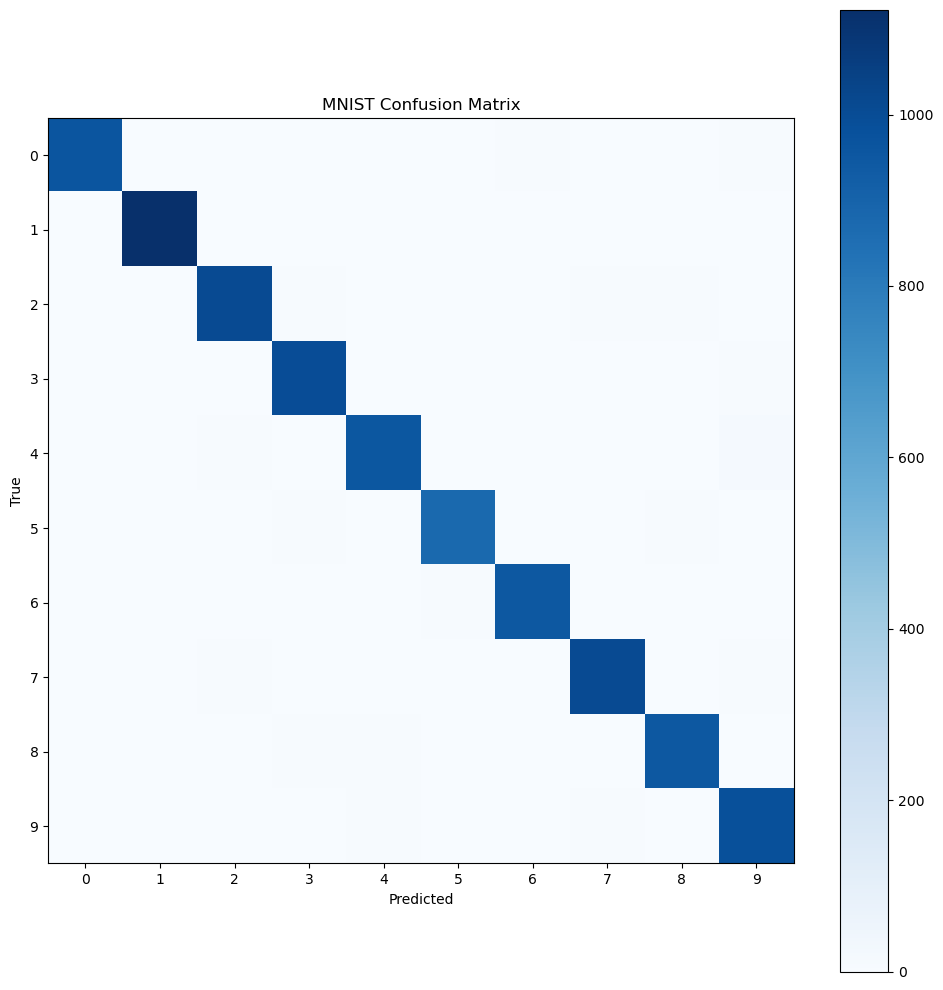

In [19]:
# retrain final model on full training data (train + val) and evaluate on test
full_loader = DataLoader(train_full, batch_size=batch_size, shuffle=True)

final_model = MLP(units=best_units).to(device)
optimizer   = optim.Adam(final_model.parameters(), lr=lr)
loss_fn     = nn.CrossEntropyLoss()

final_epochs = 10
for ep in range(1, final_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(final_model, full_loader, optimizer, loss_fn)
    print(f'Final Epoch {ep} | train_acc={tr_acc}')

test_loss, test_acc = evaluate(final_model, test_loader, loss_fn)
print(f'Test accuracy: {test_acc} | Test loss: {test_loss}')

# confusion matrix (10x10)
@torch.no_grad()
def compute_confusion_matrix(model, loader, num_classes=10):
    model.eval()
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu()
        y = y.cpu()
        for t, p in zip(y, preds):
            cm[t, p] += 1
    return cm

cm = compute_confusion_matrix(final_model, test_loader, num_classes=10)
print('Confusion matrix:\n', cm.numpy())

plt.figure(figsize=(10,10))
plt.imshow(cm.numpy(), cmap='Blues')
plt.title('MNIST Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

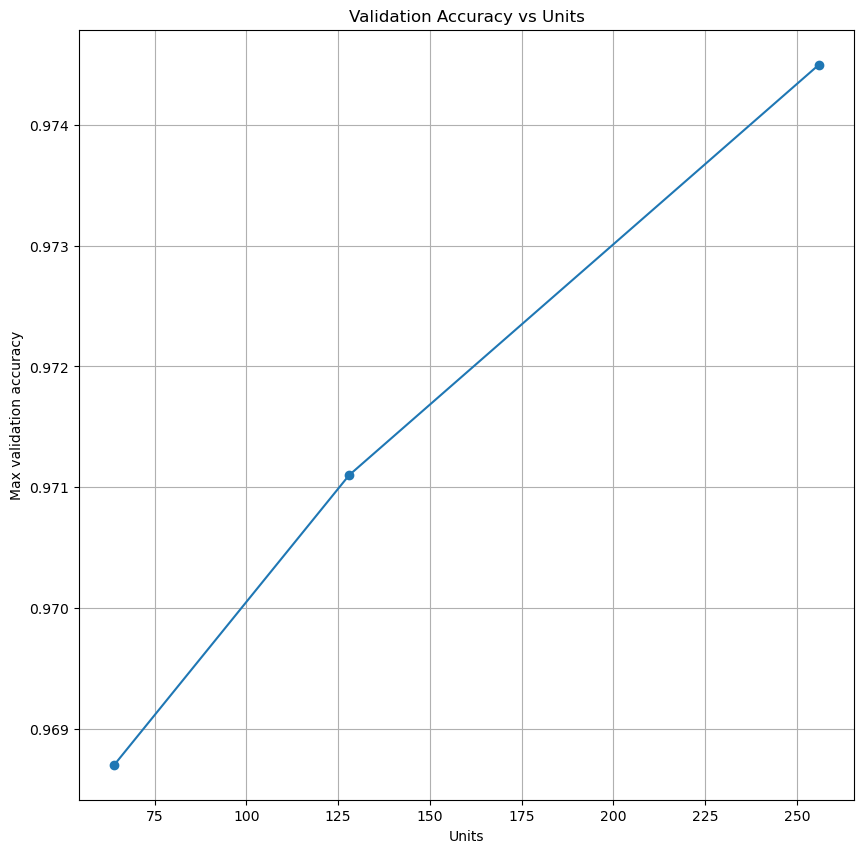

In [20]:
# plot validation accuracy across hidden units
plt.figure(figsize=(10,10))
xs = sorted(history.keys())
ys = [max(history[u]) for u in xs]
plt.plot(xs, ys, marker='o')
plt.title('Validation Accuracy vs Units')
plt.xlabel('Units')
plt.ylabel('Max validation accuracy')
plt.grid(True)
plt.show()

Sample 0: True=7 | Pred=7 | Probabilities=[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


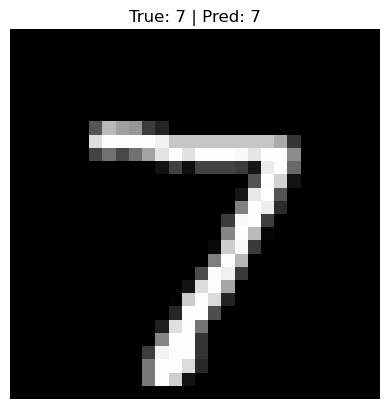

Sample 1: True=2 | Pred=2 | Probabilities=[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


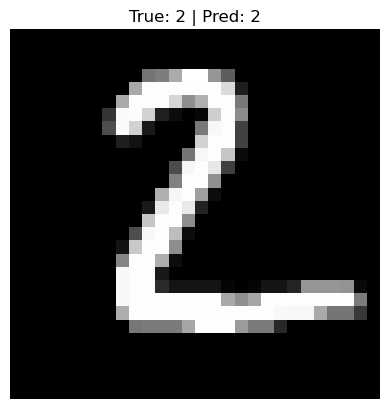

Sample 2: True=1 | Pred=1 | Probabilities=[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


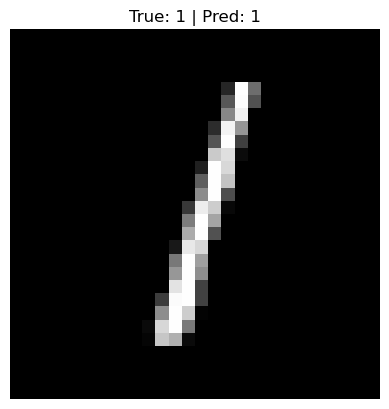

Sample 3: True=0 | Pred=0 | Probabilities=[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


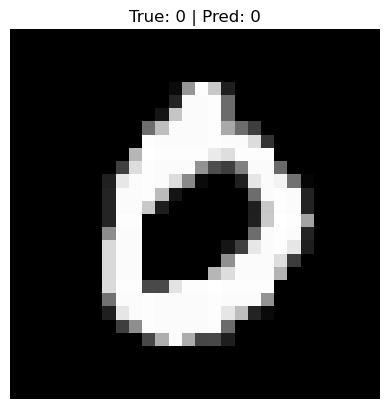

Sample 4: True=4 | Pred=4 | Probabilities=[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


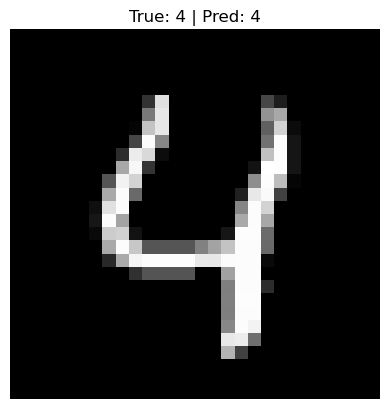

Sample 5: True=1 | Pred=1 | Probabilities=[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


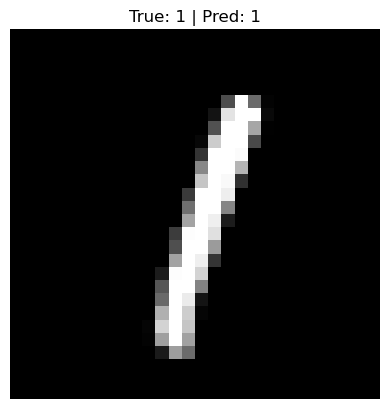

Sample 6: True=4 | Pred=4 | Probabilities=[0.    0.    0.    0.    0.999 0.    0.    0.    0.    0.001]


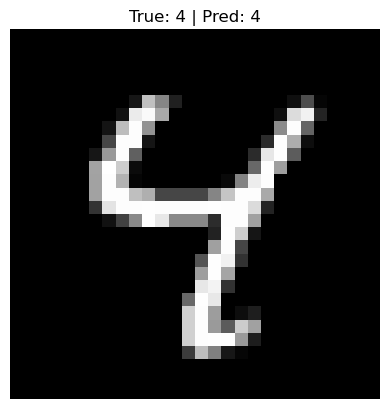

Sample 7: True=9 | Pred=9 | Probabilities=[0.    0.    0.    0.001 0.    0.    0.    0.    0.    0.999]


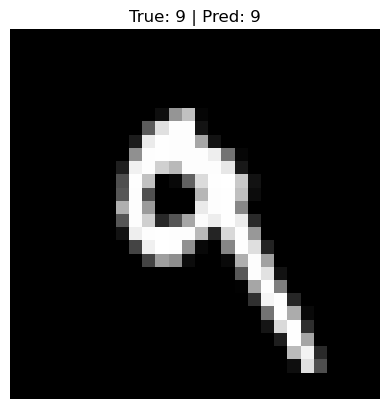

Sample 8: True=5 | Pred=5 | Probabilities=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


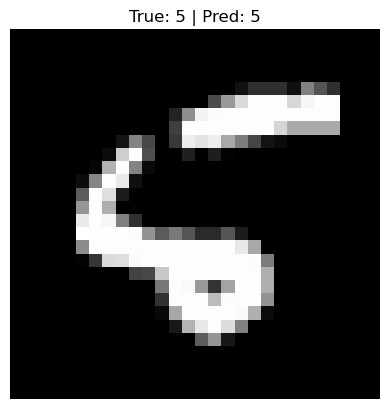

Sample 9: True=9 | Pred=9 | Probabilities=[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


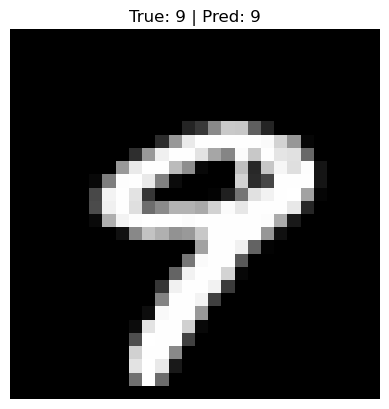

In [21]:
# use softmax to get probabilities
@torch.no_grad()
def predict_proba(model, x):
    model.eval()
    logits = model(x.to(device))
    probs = torch.softmax(logits, dim=1)
    return probs.cpu()

# take a small batch from test set
test_batch = next(iter(test_loader))
images, labels = test_batch
probs = predict_proba(final_model, images[:10])

for i in range(10):
    p = probs[i].numpy()
    pred = p.argmax()
    print(f'Sample {i}: True={labels[i].item()} | Pred={pred} | Probabilities={np.round(p, 3)}')
    plt.imshow(images[i].squeeze().numpy(), cmap='gray')
    plt.title(f'True: {labels[i].item()} | Pred: {pred}')
    plt.axis('off')
    plt.show()